# Case Study Group 01

This notebook builds the processed dataset for the case study from the unchanged raw files. The analysis follows the usual workflow: import the data, inspect its structure, clean the files that are needed, merge the relevant tables, aggregate the result, and interpret the final numbers.

The business focus is manufacturer `205`. We compare its gearbox parts with the competition in OEM1 vehicles, especially for market share, gearbox coverage, and defect frequency. The result is a compact final dataset that can be used by the web application and still remains traceable to the detailed vehicle, gearbox, and part records used during validation.


## Analysis Strategy

The case study asks three connected questions, so the notebook keeps the workflow close to the data relationships. First, the relevant OEM1 vehicles of type `11` and `12` are selected. Then the installed gearbox families are derived from the vehicle component files. For these gearboxes, the notebook identifies the installed individual part types and loads only the production files that are needed for those parts.

The detailed joins are built with vehicle IDs, gearbox IDs, part IDs, and part types. This detailed table is used for validation before any aggregation is done. The final dataset is then summarized into two record types: `part_summary` for market share and defect frequency, and `gearbox_summary` for the question about how often gearboxes contain at least one part from manufacturer `205`.


# Import

The raw files are read from `Case_Study_Data` with relative paths. The notebook keeps the original files unchanged and does all technical fixes in code, so the same workflow can be rerun on another machine with the same folder structure.


In [1]:
import os
from importlib import import_module

os.environ.setdefault("MPLCONFIGDIR", "tmp/matplotlib")

required_packages = ["pandas", "matplotlib.pyplot", "openpyxl"]
missing_packages = []

for package_name in required_packages:
    try:
        import_module(package_name)
    except ImportError:
        missing_packages.append(package_name)

if missing_packages:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_packages)
        + ". Please use an up-to-date Anaconda or Miniforge environment, "
        + "or create the environment from environment.yml."
    )


In [2]:
import os
import re
from pathlib import Path
from io import StringIO

os.environ.setdefault("MPLCONFIGDIR", "tmp/matplotlib")

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
DATA_DIR = Path("Case_Study_Data")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR.resolve()}")

The first scan shows that the raw files do not use one uniform format. Some files use commas, others use semicolons or special text separators, and a few text files do not contain normal line breaks. Therefore, the notebook inspects the format before reading a file into a dataframe.


The helper functions below handle the technical import work: listing raw files, reading a safe text sample, detecting likely separators, and loading tables with consistent column names. Files that need special handling are flagged first and parsed explicitly later.


In [4]:
SAMPLE_BYTES = 80_000
LONG_FIRST_LINE_BYTES = 1_000_000


def raw_data_files(data_dir=DATA_DIR):
    """Return raw CSV, TXT, and Excel files from the data folder."""
    suffixes = {".csv", ".txt", ".xlsx", ".xls"}
    return sorted(
        path for path in data_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in suffixes
    )


def read_sample_text(path, nbytes=SAMPLE_BYTES):
    """Read a small text sample without loading the complete file."""
    raw = path.read_bytes()[:nbytes]
    for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
        try:
            return raw.decode(encoding), encoding
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace"), "utf-8-replace"


def first_line_length(path, chunk_size=64_000, max_bytes=LONG_FIRST_LINE_BYTES):
    """Count bytes until a row break, but stop after a safe limit."""
    count = 0
    with path.open("rb") as file:
        while count <= max_bytes and (chunk := file.read(chunk_size)):
            row_breaks = (chunk.find(b"\n"), chunk.find(b"\r"), chunk.find(b"\x0b"))
            positions = [position for position in row_breaks if position >= 0]
            if positions:
                return count + min(positions)
            count += len(chunk)
    return count

In [5]:
def infer_format(path):
    """Infer separator, row separator, encoding, and warning flags."""
    text, encoding = read_sample_text(path)

    if " | | " in text:
        sep, sep_name = r"\s*\|\s*\|\s*", "pipe_pipe"
    common_separators_found = any(
        text.count(separator) > 10 for separator in [",", ";", "\t", "|"]
    )
    if text.count("II") > 10 and not common_separators_found:
        sep, sep_name = "II", "double_i"
    else:
        candidates = {"semicolon": ";", "comma": ",", "tab": "\t", "pipe": "|"}
        sep_name, sep = max(candidates.items(), key=lambda item: text.count(item[1]))
        if text.count(sep) == 0 and text.count("  ") > 10:
            sep, sep_name = r"\s{2,}", "double_space"
        elif text.count(sep) == 0:
            sep, sep_name = None, "unknown"

    row_sep, row_sep_name = None, "single_line_or_pattern_based"
    for name, value in {"lf": "\n", "cr": "\r", "vertical_tab": "\x0b"}.items():
        if value in text:
            row_sep, row_sep_name = value, name
            break

    warnings = []
    line_length = first_line_length(path)
    if line_length > LONG_FIRST_LINE_BYTES:
        warnings.append("very_long_first_line")
    if row_sep_name == "single_line_or_pattern_based":
        warnings.append("needs_custom_parser")
    if sep_name not in {"comma", "semicolon", "tab", "pipe"}:
        warnings.append(f"special_separator:{sep_name}")
    if path.name == "Einzelteil_T23.csv" and path.parent == DATA_DIR:
        warnings.append("duplicate_file")

    return {
        "encoding": encoding,
        "sep": sep,
        "sep_name": sep_name,
        "row_sep": row_sep,
        "row_sep_name": row_sep_name,
        "first_line_mb": round(line_length / 1_000_000, 2),
        "warnings": warnings,
    }

In [6]:
def clean_columns(df):
    """Remove exported index columns and strip column names."""
    df = df.copy()
    df.columns = [str(column).strip().strip('"') for column in df.columns]
    empty_columns = [
        column
        for column in df.columns
        if column == "" or column.startswith("Unnamed:")
    ]
    return df.drop(columns=empty_columns, errors="ignore")


def read_raw_table(path, nrows=None):
    """Read a raw table with the detected settings."""
    file_format = infer_format(path)

    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path, nrows=nrows)
    if "needs_custom_parser" in file_format["warnings"]:
        raise ValueError(f"Custom parser needed for {path.relative_to(DATA_DIR)}")

    if file_format["row_sep_name"] in {"cr", "vertical_tab"}:
        text, _ = read_sample_text(path, nbytes=2_000_000)
        text = text.replace(file_format["row_sep"], "\n")
        df = pd.read_csv(
            StringIO(text),
            sep=file_format["sep"],
            engine="python",
            nrows=nrows,
        )
    else:
        engine = "python" if file_format["sep"] and len(file_format["sep"]) > 1 else "c"
        df = pd.read_csv(
            path,
            sep=file_format["sep"],
            engine=engine,
            encoding=file_format["encoding"],
            nrows=nrows,
            na_values=["NA", "", "nan"],
            keep_default_na=True,
            low_memory=False,
        )
    return clean_columns(df)


def file_overview(files):
    """Create a compact overview of file size and detected format."""
    rows = []
    for path in files:
        fmt = infer_format(path) if path.suffix.lower() in {".csv", ".txt"} else {}
        rows.append({
            "folder": path.parent.relative_to(DATA_DIR).as_posix(),
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1_000_000, 2),
            "separator": fmt.get("sep_name", "excel"),
            "row_separator": fmt.get("row_sep_name", "excel"),
            "first_line_mb": fmt.get("first_line_mb"),
            "warnings": ", ".join(fmt.get("warnings", [])),
        })
    return pd.DataFrame(rows)

In [7]:
raw_files = raw_data_files()
overview = file_overview(raw_files)

overview.head(15)

,folder,file,size_mb,separator,row_separator,first_line_mb,warnings
0,Einzelteil,Einzelteil_T01.txt,638.75,pipe,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
1,Einzelteil,Einzelteil_T02.txt,336.13,tab,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
2,Einzelteil,Einzelteil_T03.txt,91.97,pipe,vertical_tab,0.00,
3,Einzelteil,Einzelteil_T04.csv,92.00,semicolon,lf,0.00,
4,Einzelteil,Einzelteil_T05.csv,105.21,comma,lf,0.00,
5,Einzelteil,Einzelteil_T06.csv,92.11,comma,lf,0.00,
6,Einzelteil,Einzelteil_T07.txt,30.81,tab,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
7,Einzelteil,Einzelteil_T08.csv,31.19,comma,lf,0.00,
8,Einzelteil,Einzelteil_T09.txt,35.71,unknown,vertical_tab,0.00,special_separator:unknown
9,Einzelteil,Einzelteil_T10.csv,31.60,semicolon,lf,0.00,


# Explore

Now we inspect the available raw data before making changes. The goal is to understand folder structure, file formats, possible import problems, and the first relevant tables for the case study.

## Dataset Structure

This overview shows how many files are stored in each folder and how large the folders are. It also makes clear why we should not load every file at once.

In [8]:
overview.groupby("folder").agg(
    files=("file", "count"),
    total_size_mb=("size_mb", "sum"),
).reset_index()

,folder,files,total_size_mb
0,.,1,172.08
1,Einzelteil,38,4341.21
2,Fahrzeug,9,598.68
3,Geodaten,5,0.37
4,Komponente,32,2399.26
5,Logistikverzug,2,31.82
6,Zulassungen,1,164.23


## Import Problems

The following files need attention during cleaning. The relevant files with unusual formats are handled explicitly in the cleaning section instead of being loaded with a generic CSV reader.

In [9]:
problem_files = overview[overview["warnings"].ne("")].sort_values(
    ["first_line_mb", "size_mb"],
    ascending=False,
)

problem_files.head(20)

,folder,file,size_mb,separator,row_separator,first_line_mb,warnings
0,Einzelteil,Einzelteil_T01.txt,638.75,pipe,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
1,Einzelteil,Einzelteil_T02.txt,336.13,tab,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
21,Einzelteil,Einzelteil_T22.txt,282.98,tab,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
28,Einzelteil,Einzelteil_T31.txt,210.92,double_space,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser, spe..."
10,Einzelteil,Einzelteil_T11.txt,189.12,tab,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
15,Einzelteil,Einzelteil_T16.txt,161.59,pipe,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
31,Einzelteil,Einzelteil_T34.txt,92.21,pipe,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser"
23,Einzelteil,Einzelteil_T24.txt,84.11,double_space,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser, spe..."
32,Einzelteil,Einzelteil_T35.txt,71.84,unknown,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser, spe..."
33,Einzelteil,Einzelteil_T36.txt,44.27,double_space,single_line_or_pattern_based,1.02,"very_long_first_line, needs_custom_parser, spe..."


## Duplicate File Check

The file `Einzelteil_T23.csv` occurs twice. We should use the version in the `Einzelteil` folder and ignore the duplicate in the root data folder.

In [10]:
overview[overview["file"].eq("Einzelteil_T23.csv")]

,folder,file,size_mb,separator,row_separator,first_line_mb,warnings
22,Einzelteil,Einzelteil_T23.csv,172.08,semicolon,lf,0.0,
38,.,Einzelteil_T23.csv,172.08,semicolon,lf,0.0,duplicate_file


## First Table Check

As a first readable example, we load a small sample from an OEM1 vehicle file. This checks whether separator detection and the removal of exported index columns work as expected.

In [11]:
example_file = DATA_DIR / "Fahrzeug" / "Fahrzeuge_OEM1_Typ12.csv"
example_data = read_raw_table(example_file, nrows=5)

example_data

,X1,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1,12-1-12-1,2008-11-19,1,12,0,NaN,0
1,2,12-1-12-2,2008-11-19,1,12,0,NaN,0
2,3,12-1-12-3,2008-11-19,1,12,0,NaN,0
3,4,12-1-12-4,2008-11-19,1,12,0,NaN,0
4,5,12-1-12-5,2008-11-19,1,12,0,NaN,0


In [12]:
pd.DataFrame({
    "dtype": example_data.dtypes.astype(str),
    "missing_values": example_data.isna().sum(),
    "unique_values": example_data.nunique(dropna=True),
})

,dtype,missing_values,unique_values
X1,int64,0,5
ID_Fahrzeug,str,0,5
Produktionsdatum,str,0,1
Herstellernummer,int64,0,1
Werksnummer,int64,0,1
Fehlerhaft,int64,0,1
Fehlerhaft_Datum,float64,5,0
Fehlerhaft_Fahrleistung,int64,0,1


## Relevant Starting Files

The analysis starts with OEM1 vehicles of type `11` and `12`. These are the vehicle tables and component mapping tables needed to identify which gearbox is installed in each vehicle.


In [13]:
oem1_start_files = [
    DATA_DIR / "Fahrzeug" / "Fahrzeuge_OEM1_Typ11.csv",
    DATA_DIR / "Fahrzeug" / "Fahrzeuge_OEM1_Typ12.csv",
    DATA_DIR / "Fahrzeug" / "Bestandteile_Fahrzeuge_OEM1_Typ11.csv",
    DATA_DIR / "Fahrzeug" / "Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
]

pd.DataFrame({
    "file": [path.relative_to(DATA_DIR).as_posix() for path in oem1_start_files],
    "exists": [path.exists() for path in oem1_start_files],
})

,file,exists
0,Fahrzeug/Fahrzeuge_OEM1_Typ11.csv,True
1,Fahrzeug/Fahrzeuge_OEM1_Typ12.csv,True
2,Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv,True
3,Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv,True


## Gearbox Families Installed in OEM1 Vehicles

The next step derives the gearbox families from the OEM1 component mappings. We use the gearbox ID in `ID_Schaltung` and take the family prefix, for example `K3SG1` from a full gearbox ID. This confirms the gearbox families used later in the analysis instead of only stating them manually.


In [14]:
oem1_component_frames = []

for path in oem1_start_files[2:]:
    component_mapping = read_raw_table(path)
    component_mapping["source_file"] = path.name
    oem1_component_frames.append(component_mapping)

oem1_components = pd.concat(oem1_component_frames, ignore_index=True)
oem1_components.head()

,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug,source_file
0,K4-112-1121-3,K3SG1-105-1051-32,K2LE1-109-1091-2,K1BE1-101-1011-7,11-1-11-1,Bestandteile_Fahrzeuge_OEM1_Typ11.csv
1,K4-112-1121-4,K3SG1-105-1051-141,K2ST1-109-1092-5,K1BE1-101-1011-12,11-1-11-2,Bestandteile_Fahrzeuge_OEM1_Typ11.csv
2,K4-112-1121-7,K3SG1-105-1051-106,K2ST1-109-1092-57,K1BE1-101-1011-38,11-1-11-3,Bestandteile_Fahrzeuge_OEM1_Typ11.csv
3,K4-112-1121-9,K3SG1-105-1051-21,K2ST1-109-1092-91,K1BE1-101-1011-97,11-1-11-4,Bestandteile_Fahrzeuge_OEM1_Typ11.csv
4,K4-112-1121-11,K3SG1-105-1051-59,K2ST1-109-1092-4,K1BE1-101-1011-65,11-1-11-5,Bestandteile_Fahrzeuge_OEM1_Typ11.csv


In [15]:
gearbox_ids = oem1_components["ID_Schaltung"].dropna().astype("string")
gearbox_families = gearbox_ids.str.split("-").str[0]

gearbox_family_overview = (
    pd.DataFrame({
        "gearbox_id": gearbox_ids,
        "gearbox_family": gearbox_families,
    })
    .groupby("gearbox_family", as_index=False)
    .agg(
        installed_rows=("gearbox_id", "size"),
        unique_gearboxes=("gearbox_id", "nunique"),
    )
    .sort_values("gearbox_family")
)

gearbox_family_overview

,gearbox_family,installed_rows,unique_gearboxes
0,K3AG1,477052,477052
1,K3SG1,1908208,1908208


## Gearbox Component Files Needed

For each gearbox family found in OEM1 vehicles, we expect a matching component parts list in the `Komponente` folder. These files tell us which individual parts are installed in each gearbox.

In [16]:
gearbox_bom_files = pd.DataFrame({
    "gearbox_family": sorted(gearbox_families.dropna().unique()),
})
gearbox_bom_files["bom_file"] = gearbox_bom_files["gearbox_family"].apply(
    lambda family: DATA_DIR / "Komponente" / f"Bestandteile_Komponente_{family}.csv"
)
gearbox_bom_files["exists"] = gearbox_bom_files["bom_file"].apply(Path.exists)
gearbox_bom_files["relative_path"] = gearbox_bom_files["bom_file"].apply(
    lambda path: path.relative_to(DATA_DIR).as_posix()
)

gearbox_bom_files[["gearbox_family", "relative_path", "exists"]]

,gearbox_family,relative_path,exists
0,K3AG1,Komponente/Bestandteile_Komponente_K3AG1.csv,True
1,K3SG1,Komponente/Bestandteile_Komponente_K3SG1.csv,True


## Individual Part Types Used in These Gearboxes

For the selected gearbox families, the component part lists show which individual part columns occur. These `ID_T...` columns define the relevant individual part files for the analysis.


In [17]:
relevant_part_rows = []

for row in gearbox_bom_files.itertuples(index=False):
    gearbox_bom = read_raw_table(row.bom_file)
    gearbox_key = f"ID_{row.gearbox_family}"
    installed_gearbox_ids = set(gearbox_ids[gearbox_families.eq(row.gearbox_family)])
    relevant_bom_rows = gearbox_bom[
        gearbox_bom[gearbox_key].isin(installed_gearbox_ids)
    ]

    part_columns = [
        column for column in relevant_bom_rows.columns
        if column.startswith("ID_T")
    ]
    for column in part_columns:
        part_ids = relevant_bom_rows[column].dropna().astype("string")
        if part_ids.empty:
            continue
        part_type = column.removeprefix("ID_")
        matching_files = sorted(
            (DATA_DIR / "Einzelteil").glob(f"Einzelteil_{part_type}.*")
        )
        relevant_part_rows.append({
            "gearbox_family": row.gearbox_family,
            "part_type": part_type,
            "installed_part_rows": len(part_ids),
            "unique_part_ids": part_ids.nunique(),
            "part_file_found": len(matching_files) == 1,
            "part_file": (
                matching_files[0].relative_to(DATA_DIR).as_posix()
                if matching_files
                else None
            ),
        })

relevant_part_files = (
    pd.DataFrame(relevant_part_rows)
    .sort_values(["gearbox_family", "part_type"])
    .reset_index(drop=True)
)

relevant_part_files

,gearbox_family,part_type,installed_part_rows,unique_part_ids,part_file_found,part_file
0,K3AG1,T21,477052,477052,True,Einzelteil/Einzelteil_T21.csv
1,K3AG1,T24,477052,477052,True,Einzelteil/Einzelteil_T24.txt
2,K3AG1,T25,477052,477052,True,Einzelteil/Einzelteil_T25.csv
3,K3SG1,T21,1908208,1908208,True,Einzelteil/Einzelteil_T21.csv
4,K3SG1,T22,1908208,1908208,True,Einzelteil/Einzelteil_T22.txt
5,K3SG1,T23,1908208,1908208,True,Einzelteil/Einzelteil_T23.csv


The selected part types are derived from the gearbox part lists. This table is the link between the business focus on the two gearbox families and the individual part files used later.


In [18]:
gearbox_part_selection = (
    relevant_part_files.groupby("gearbox_family")
    .agg(
        relevant_part_types=(
            "part_type",
            lambda values: ", ".join(
                sorted(values.unique(), key=lambda value: int(value[1:]))
            ),
        ),
        installed_part_rows=("installed_part_rows", "sum"),
        all_part_files_found=("part_file_found", "all"),
    )
    .reset_index()
)

selected_part_types = sorted(
    relevant_part_files["part_type"].unique(),
    key=lambda value: int(value[1:]),
)

pd.DataFrame({
    "selected_gearbox_families": [", ".join(gearbox_part_selection["gearbox_family"])],
    "selected_part_types": [", ".join(selected_part_types)],
})


,selected_gearbox_families,selected_part_types
0,"K3AG1, K3SG1","T21, T22, T23, T24, T25"


In [19]:
gearbox_part_selection


,gearbox_family,relevant_part_types,installed_part_rows,all_part_files_found
0,K3AG1,"T21, T24, T25",1431156,True
1,K3SG1,"T21, T22, T23",5724624,True


In [20]:
required_part_types = sorted(
    relevant_part_files["part_type"].unique(),
    key=lambda value: int(value[1:]),
)

required_part_types

['T21', 'T22', 'T23', 'T24', 'T25']

## Simple Format Visualization

This plot is not a result of the case study yet. It only summarizes the import formats we found during EDA.

<Axes: title={'center': 'Detected separators in raw files'}, xlabel='Detected separator', ylabel='Number of files'>

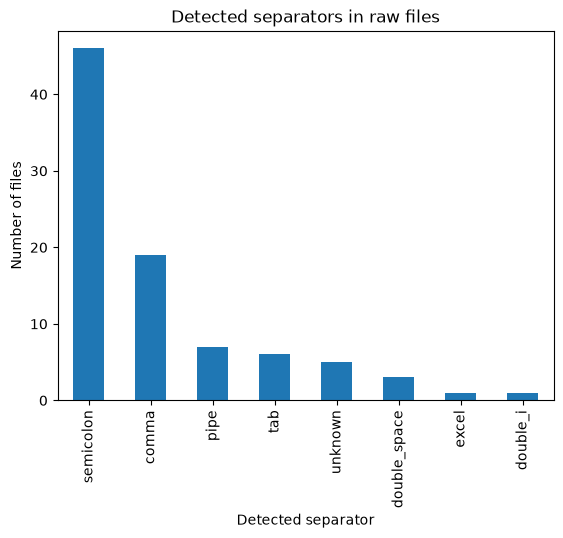

In [21]:
overview["separator"].value_counts().plot(
    kind="bar",
    title="Detected separators in raw files",
    xlabel="Detected separator",
    ylabel="Number of files",
)

# Clean

Only the files needed for the OEM1 gearbox analysis are cleaned further. The common steps are to remove exported index columns, normalize date and defect columns, repair the required files with unusual text formats, and check whether key columns are unique before merging. The raw files stay unchanged; all corrections happen in memory while the notebook runs.


In [22]:
OUTPUT_DIR = Path("Data")
FINAL_FILE_NAME = "SoSe26_Case_Study_finalData_Group_01.csv"
FINAL_DATA_PATH = OUTPUT_DIR / FINAL_FILE_NAME
ROOT_FINAL_DATA_PATH = Path(FINAL_FILE_NAME)


def read_t22(path):
    """Read T22, which is tab-separated but stored without normal row breaks."""
    text = path.read_text(encoding="utf-8-sig")
    row_start = re.compile(r'(?="\d+"\t(?:\d+|NA)\t(?:"|NA))')
    text = row_start.sub("\n", text).lstrip("\n")
    data = pd.read_csv(
        StringIO(text),
        sep="\t",
        na_values=["NA", "", "nan"],
        keep_default_na=True,
        low_memory=False,
    )
    return clean_columns(data)


def read_t24(path):
    """Read T24, which uses form-feed row breaks and double spaces."""
    text = path.read_text(encoding="utf-8-sig").replace("\x0c", "\n")
    data = pd.read_csv(
        StringIO(text),
        sep=r"\s{2,}",
        engine="python",
        na_values=["NA", "", "nan"],
        keep_default_na=True,
    )
    return clean_columns(data)


def read_part_table(part_type):
    """Read one required individual-part table with the correct reader."""
    matches = sorted(
        (DATA_DIR / "Einzelteil").glob(f"Einzelteil_{part_type}.*")
    )
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected one file for {part_type}, found {matches}")
    path = matches[0]
    if part_type == "T22":
        return read_t22(path)
    if part_type == "T24":
        return read_t24(path)
    return read_raw_table(path)


In [23]:
def coalesce_source_blocks(data, id_column):
    """Combine .x/.y/final column blocks after checking for conflicts."""
    fields = [
        id_column,
        "Produktionsdatum",
        "Herstellernummer",
        "Werksnummer",
        "Fehlerhaft",
        "Fehlerhaft_Datum",
        "Fehlerhaft_Fahrleistung",
    ]
    result = pd.DataFrame(index=data.index)

    for field in fields:
        candidates = [
            column for column in (f"{field}.x", f"{field}.y", field)
            if column in data.columns
        ]
        if not candidates:
            continue

        non_null_sources = data[candidates].notna().sum(axis=1)
        if (non_null_sources > 1).any():
            comparable = data.loc[non_null_sources > 1, candidates].astype("string")
            conflicts = comparable.nunique(axis=1, dropna=True) > 1
            if conflicts.any():
                raise ValueError(f"Conflicting source values for {field}")

        combined = data[candidates[0]].copy()
        for candidate in candidates[1:]:
            combined = combined.combine_first(data[candidate])
        result[field] = combined

    return result


def normalize_production_table(data, id_column):
    """Create one consistent schema for vehicle, gearbox, or part production data."""
    data = clean_columns(data)
    if any(column.endswith((".x", ".y")) for column in data.columns):
        data = coalesce_source_blocks(data, id_column)
    else:
        keep_columns = [
            id_column,
            "Produktionsdatum",
            "Herstellernummer",
            "Werksnummer",
            "Fehlerhaft",
            "Fehlerhaft_Datum",
            "Fehlerhaft_Fahrleistung",
            "Produktionsdatum_Origin_01011970",
            "origin",
        ]
        available_columns = [
            column for column in keep_columns if column in data.columns
        ]
        data = data[available_columns].copy()

    if "Produktionsdatum" not in data.columns:
        origin = pd.to_datetime(data["origin"], dayfirst=True, errors="coerce")
        offset = pd.to_numeric(
            data["Produktionsdatum_Origin_01011970"], errors="coerce"
        )
        data["Produktionsdatum"] = origin + pd.to_timedelta(offset, unit="D")
    else:
        data["Produktionsdatum"] = pd.to_datetime(
            data["Produktionsdatum"], errors="coerce"
        )

    if "Fehlerhaft_Datum" in data.columns:
        data["Fehlerhaft_Datum"] = pd.to_datetime(
            data["Fehlerhaft_Datum"], errors="coerce"
        )
    else:
        data["Fehlerhaft_Datum"] = pd.NaT

    if "Fehlerhaft_Fahrleistung" not in data.columns:
        data["Fehlerhaft_Fahrleistung"] = pd.NA

    data["Fehlerhaft"] = (
        pd.to_numeric(data["Fehlerhaft"], errors="coerce").astype("Int8")
    )
    data["Fehlerhaft_Fahrleistung"] = pd.to_numeric(
        data["Fehlerhaft_Fahrleistung"], errors="coerce"
    )

    for column in [id_column, "Herstellernummer", "Werksnummer"]:
        data[column] = (
            data[column]
            .astype("string")
            .str.strip()
            .str.strip('"')
            .str.replace(r"\.0$", "", regex=True)
        )

    data = data.dropna(subset=[id_column]).copy()
    duplicate_ids = data[id_column].duplicated(keep=False)
    if duplicate_ids.any():
        duplicate_rows = data.loc[duplicate_ids]
        has_conflicts = (
            duplicate_rows.groupby(id_column).nunique(dropna=False) > 1
        ).any(axis=None)
        if has_conflicts:
            raise ValueError(f"Conflicting duplicate records in {id_column}")
        data = data.drop_duplicates(id_column)

    return data


# Transform

The detailed table is built first because it is the safest way to validate the joins. One row represents one relevant individual part installed in one selected gearbox in one OEM1 vehicle. After these checks, the detailed table is aggregated to the compact dataset used by the app and the report.


In [24]:
def load_oem1_vehicle_data():
    """Load OEM1 vehicle tables and their component mappings."""
    vehicle_frames = []
    mapping_frames = []

    for vehicle_type in ["11", "12"]:
        vehicle_path = DATA_DIR / "Fahrzeug" / f"Fahrzeuge_OEM1_Typ{vehicle_type}.csv"
        mapping_path = (
            DATA_DIR
            / "Fahrzeug"
            / f"Bestandteile_Fahrzeuge_OEM1_Typ{vehicle_type}.csv"
        )

        vehicles = normalize_production_table(
            read_raw_table(vehicle_path), "ID_Fahrzeug"
        )
        vehicles["vehicle_type"] = vehicle_type
        vehicle_frames.append(vehicles)

        mappings = read_raw_table(mapping_path)
        mappings["vehicle_type"] = vehicle_type
        mapping_frames.append(mappings)

    vehicles = pd.concat(vehicle_frames, ignore_index=True)
    mappings = pd.concat(mapping_frames, ignore_index=True)

    if not vehicles["ID_Fahrzeug"].is_unique:
        raise AssertionError("OEM1 vehicle IDs are not unique")
    if not mappings["ID_Fahrzeug"].is_unique:
        raise AssertionError("OEM1 vehicle mapping IDs are not unique")

    merged = vehicles.merge(
        mappings,
        on=["ID_Fahrzeug", "vehicle_type"],
        how="left",
        validate="one_to_one",
        indicator="vehicle_mapping_match",
    )
    if not merged["vehicle_mapping_match"].eq("both").all():
        raise AssertionError("Some OEM1 vehicles have no component mapping")

    merged = merged.drop(columns="vehicle_mapping_match")
    merged["gearbox_family"] = (
        merged["ID_Schaltung"].astype("string").str.split("-").str[0]
    )
    return merged


oem1_vehicle_data = load_oem1_vehicle_data()
oem1_vehicle_data[[
    "ID_Fahrzeug",
    "vehicle_type",
    "ID_Schaltung",
    "gearbox_family",
]].head()


,ID_Fahrzeug,vehicle_type,ID_Schaltung,gearbox_family
0,11-1-11-1,11,K3SG1-105-1051-32,K3SG1
1,11-1-11-2,11,K3SG1-105-1051-141,K3SG1
2,11-1-11-3,11,K3SG1-105-1051-106,K3SG1
3,11-1-11-4,11,K3SG1-105-1051-21,K3SG1
4,11-1-11-5,11,K3SG1-105-1051-59,K3SG1


In [25]:
def load_gearbox_production(gearbox_families):
    """Load production data for the gearbox families installed in OEM1 vehicles."""
    frames = []
    for family in sorted(gearbox_families):
        path = DATA_DIR / "Komponente" / f"Komponente_{family}.csv"
        raw = read_raw_table(path)
        gearbox = normalize_production_table(raw, "ID_Schaltung")
        gearbox["gearbox_family"] = family
        frames.append(gearbox)

    gearbox_data = pd.concat(frames, ignore_index=True)
    return gearbox_data.rename(
        columns={
            "ID_Schaltung": "gearbox_id",
            "Produktionsdatum": "gearbox_production_date",
            "Herstellernummer": "gearbox_manufacturer",
            "Werksnummer": "gearbox_plant",
            "Fehlerhaft": "gearbox_defective",
            "Fehlerhaft_Datum": "gearbox_defect_date",
            "Fehlerhaft_Fahrleistung": "gearbox_defect_mileage",
        }
    )


gearbox_data = load_gearbox_production(gearbox_family_overview["gearbox_family"])
gearbox_data.head()

,gearbox_id,gearbox_production_date,gearbox_manufacturer,gearbox_plant,gearbox_defective,gearbox_defect_date,gearbox_defect_mileage,gearbox_family
0,K3AG1-105-1051-36,2008-11-13,105,1051,0,NaT,0.0,K3AG1
1,K3AG1-105-1051-5,2008-11-13,105,1051,0,NaT,0.0,K3AG1
2,K3AG1-105-1051-28,2008-11-13,105,1051,0,NaT,0.0,K3AG1
3,K3AG1-105-1051-15,2008-11-13,105,1051,0,NaT,0.0,K3AG1
4,K3AG1-105-1051-16,2008-11-13,105,1051,1,2009-03-20,8415.0,K3AG1


In [26]:
def load_relevant_gearbox_parts(gearbox_bom_files, installed_gearbox_ids):
    """Load gearbox BOM rows and reshape installed part IDs to long format."""
    frames = []

    for row in gearbox_bom_files.itertuples(index=False):
        bom = read_raw_table(row.bom_file)
        gearbox_key = f"ID_{row.gearbox_family}"
        bom[gearbox_key] = bom[gearbox_key].astype("string")
        bom = bom[bom[gearbox_key].isin(installed_gearbox_ids)].copy()
        part_columns = [column for column in bom.columns if column.startswith("ID_T")]

        long_bom = bom.melt(
            id_vars=gearbox_key,
            value_vars=part_columns,
            var_name="part_key",
            value_name="part_id",
        ).rename(columns={gearbox_key: "gearbox_id"})
        long_bom["part_type"] = long_bom["part_key"].str.removeprefix("ID_")
        long_bom["gearbox_family"] = row.gearbox_family
        frames.append(long_bom.drop(columns="part_key"))

    return (
        pd.concat(frames, ignore_index=True)
        .dropna(subset=["part_id"])
    )


installed_gearbox_ids = set(
    oem1_vehicle_data["ID_Schaltung"].dropna().astype("string")
)
gearbox_parts = load_relevant_gearbox_parts(gearbox_bom_files, installed_gearbox_ids)
gearbox_parts.head()

,gearbox_id,part_id,part_type,gearbox_family
0,K3AG1-105-1051-1,21-205-2051-52,T21,K3AG1
1,K3AG1-105-1051-2,21-208-2081-78,T21,K3AG1
2,K3AG1-105-1051-3,21-205-2051-195,T21,K3AG1
3,K3AG1-105-1051-4,21-208-2081-70,T21,K3AG1
4,K3AG1-105-1051-5,21-205-2051-304,T21,K3AG1


In [27]:
def load_relevant_part_production(required_part_types):
    """Load and normalize selected individual-part files."""
    frames = []
    for part_type in required_part_types:
        raw = read_part_table(part_type)
        part_data = normalize_production_table(raw, f"ID_{part_type}")
        part_data["part_type"] = part_type
        part_data = part_data.rename(columns={f"ID_{part_type}": "part_id"})
        frames.append(part_data)

    parts = pd.concat(frames, ignore_index=True)
    if not parts["part_id"].is_unique:
        raise AssertionError("Part IDs are not unique after cleaning")

    return parts.rename(
        columns={
            "Produktionsdatum": "part_production_date",
            "Herstellernummer": "part_manufacturer",
            "Werksnummer": "part_plant",
            "Fehlerhaft": "part_defective",
            "Fehlerhaft_Datum": "part_defect_date",
            "Fehlerhaft_Fahrleistung": "part_defect_mileage",
        }
    )


part_data = load_relevant_part_production(required_part_types)
part_data.head()

,part_id,part_manufacturer,part_plant,part_defective,part_defect_date,part_defect_mileage,Produktionsdatum_Origin_01011970,origin,part_production_date,part_type
0,21-208-2081-970,208,2081,1,2010-01-03,NaN,14191.0,01-01-1970,2008-11-08,T21
1,21-208-2081-189,208,2081,0,NaT,0.0,14190.0,01-01-1970,2008-11-07,T21
2,21-208-2081-522,208,2081,0,NaT,0.0,14190.0,01-01-1970,2008-11-07,T21
3,21-208-2081-124,208,2081,0,NaT,0.0,14190.0,01-01-1970,2008-11-07,T21
4,21-205-2051-320,205,2051,0,NaT,0.0,14190.0,01-01-1970,2008-11-07,T21


Before merging, the relevant tables are checked for missing keys, duplicate keys, and the expected scope of the analysis. These checks keep the later joins easier to interpret.


In [28]:
preparation_checks = pd.DataFrame([
    {
        "table": "OEM1 vehicles",
        "rows": len(oem1_vehicle_data),
        "key_column": "ID_Fahrzeug",
        "unique_keys": oem1_vehicle_data["ID_Fahrzeug"].nunique(),
        "missing_keys": oem1_vehicle_data["ID_Fahrzeug"].isna().sum(),
        "duplicate_keys": oem1_vehicle_data["ID_Fahrzeug"].duplicated().sum(),
    },
    {
        "table": "gearbox production",
        "rows": len(gearbox_data),
        "key_column": "gearbox_id",
        "unique_keys": gearbox_data["gearbox_id"].nunique(),
        "missing_keys": gearbox_data["gearbox_id"].isna().sum(),
        "duplicate_keys": gearbox_data["gearbox_id"].duplicated().sum(),
    },
    {
        "table": "gearbox parts",
        "rows": len(gearbox_parts),
        "key_column": "gearbox_id + part_id",
        "unique_keys": gearbox_parts[["gearbox_id", "part_id"]]
        .drop_duplicates()
        .shape[0],
        "missing_keys": gearbox_parts[["gearbox_id", "part_id"]]
        .isna()
        .any(axis=1)
        .sum(),
        "duplicate_keys": gearbox_parts[["gearbox_id", "part_id"]].duplicated().sum(),
    },
    {
        "table": "part production",
        "rows": len(part_data),
        "key_column": "part_id",
        "unique_keys": part_data["part_id"].nunique(),
        "missing_keys": part_data["part_id"].isna().sum(),
        "duplicate_keys": part_data["part_id"].duplicated().sum(),
    },
])

preparation_checks


,table,rows,key_column,unique_keys,missing_keys,duplicate_keys
0,OEM1 vehicles,2385260,ID_Fahrzeug,2385260,0,0
1,gearbox production,2385260,gearbox_id,2385260,0,0
2,gearbox parts,7155780,gearbox_id + part_id,7155780,0,0
3,part production,8793468,part_id,8793468,0,0


The key checks above focus on the join columns. The next table checks the analytical fields that will be used later: production dates, defect flags, defect dates, mileage values, and manufacturer numbers. This gives a compact view of missing or implausible values before the data is merged and aggregated.


In [29]:
def quality_summary(
    data,
    table_name,
    id_column,
    date_column,
    defect_column,
    mileage_column,
    manufacturer_column,
):
    """Summarize the main quality checks for one cleaned table."""
    defect_values = pd.to_numeric(data[defect_column], errors="coerce")
    mileage_values = pd.to_numeric(data[mileage_column], errors="coerce")

    return {
        "table": table_name,
        "rows": len(data),
        "missing_ids": data[id_column].isna().sum(),
        "duplicate_ids": data[id_column].duplicated().sum(),
        "missing_production_dates": data[date_column].isna().sum(),
        "missing_manufacturers": data[manufacturer_column].isna().sum(),
        "first_production_date": data[date_column].min(),
        "last_production_date": data[date_column].max(),
        "missing_defect_flags": defect_values.isna().sum(),
        "unexpected_defect_flags": (~defect_values.dropna().isin([0, 1])).sum(),
        "negative_mileage_values": mileage_values.lt(0).sum(),
    }


data_quality_checks = pd.DataFrame([
    quality_summary(
        oem1_vehicle_data,
        "OEM1 vehicles",
        "ID_Fahrzeug",
        "Produktionsdatum",
        "Fehlerhaft",
        "Fehlerhaft_Fahrleistung",
        "Herstellernummer",
    ),
    quality_summary(
        gearbox_data,
        "gearbox production",
        "gearbox_id",
        "gearbox_production_date",
        "gearbox_defective",
        "gearbox_defect_mileage",
        "gearbox_manufacturer",
    ),
    quality_summary(
        part_data,
        "part production",
        "part_id",
        "part_production_date",
        "part_defective",
        "part_defect_mileage",
        "part_manufacturer",
    ),
])

data_quality_checks


,table,rows,missing_ids,duplicate_ids,missing_production_dates,missing_manufacturers,first_production_date,last_production_date,missing_defect_flags,unexpected_defect_flags,negative_mileage_values
0,OEM1 vehicles,2385260,0,0,0,0,2008-11-18,2016-11-30,0,0,0
1,gearbox production,2385260,0,0,0,0,2008-11-12,2016-11-15,0,0,704
2,part production,8793468,0,0,0,0,2008-11-07,2016-11-05,0,0,0


The negative mileage values appear only in the gearbox production table. They are kept visible in the quality summary but are not used for the final task calculations, which rely on installed-part counts, defect flags, manufacturers, and gearbox coverage. Because changing these mileage values would not affect the three requested results, the notebook documents the issue instead of replacing values with assumptions.


The merge plan below states the expected relationship before the joins are executed. The code uses the same relationship in `validate=...` and stops if a join does not match the expected structure.


In [30]:
merge_plan = pd.DataFrame([
    {
        "left_table": "OEM1 vehicles",
        "right_table": "gearbox production",
        "merge_keys": "gearbox_id, gearbox_family",
        "expected_relation": "many_to_one",
        "check": "each vehicle gearbox has one production record",
    },
    {
        "left_table": "vehicle gearboxes",
        "right_table": "gearbox parts",
        "merge_keys": "gearbox_id, gearbox_family",
        "expected_relation": "one_to_many",
        "check": "each gearbox expands to its installed relevant parts",
    },
    {
        "left_table": "installed gearbox parts",
        "right_table": "part production",
        "merge_keys": "part_id, part_type",
        "expected_relation": "many_to_one",
        "check": "each installed part has one production record",
    },
])

merge_plan


,left_table,right_table,merge_keys,expected_relation,check
0,OEM1 vehicles,gearbox production,"gearbox_id, gearbox_family",many_to_one,each vehicle gearbox has one production record
1,vehicle gearboxes,gearbox parts,"gearbox_id, gearbox_family",one_to_many,each gearbox expands to its installed relevant...
2,installed gearbox parts,part production,"part_id, part_type",many_to_one,each installed part has one production record


In [31]:
vehicle_gearboxes = oem1_vehicle_data.rename(
    columns={
        "ID_Fahrzeug": "vehicle_id",
        "Produktionsdatum": "vehicle_production_date",
        "Herstellernummer": "vehicle_manufacturer",
        "Werksnummer": "vehicle_plant",
        "Fehlerhaft": "vehicle_defective",
        "Fehlerhaft_Datum": "vehicle_defect_date",
        "Fehlerhaft_Fahrleistung": "vehicle_defect_mileage",
        "ID_Schaltung": "gearbox_id",
    }
)

selected_vehicle_columns = [
    "vehicle_id",
    "vehicle_type",
    "vehicle_production_date",
    "vehicle_manufacturer",
    "vehicle_plant",
    "vehicle_defective",
    "vehicle_defect_date",
    "vehicle_defect_mileage",
    "gearbox_id",
    "gearbox_family",
]
vehicle_gearboxes = vehicle_gearboxes[selected_vehicle_columns]

vehicle_gearboxes = vehicle_gearboxes.merge(
    gearbox_data,
    on=["gearbox_id", "gearbox_family"],
    how="left",
    validate="many_to_one",
    indicator="gearbox_match",
)
if not vehicle_gearboxes["gearbox_match"].eq("both").all():
    raise AssertionError("Some OEM1 gearboxes have no production record")
vehicle_gearboxes = vehicle_gearboxes.drop(columns="gearbox_match")

final_data = vehicle_gearboxes.merge(
    gearbox_parts,
    on=["gearbox_id", "gearbox_family"],
    how="left",
    validate="one_to_many",
    indicator="gearbox_part_match",
)
if not final_data["gearbox_part_match"].eq("both").all():
    raise AssertionError("Some OEM1 gearboxes have no part mapping")
final_data = final_data.drop(columns="gearbox_part_match")

final_data = final_data.merge(
    part_data,
    on=["part_id", "part_type"],
    how="left",
    validate="many_to_one",
    indicator="part_match",
)
if not final_data["part_match"].eq("both").all():
    unmatched = final_data.loc[
        final_data["part_match"].ne("both"), ["part_type", "part_id"]
    ]
    raise AssertionError(
        "Some installed parts have no production record:\n"
        f"{unmatched.head()}"
    )
final_data = final_data.drop(columns="part_match")

final_data["is_205_part"] = final_data["part_manufacturer"].eq("205")
final_data["gearbox_has_205_part"] = final_data.groupby("gearbox_id")[
    "is_205_part"
].transform("max")

final_columns = [
    "vehicle_id",
    "vehicle_type",
    "vehicle_production_date",
    "vehicle_manufacturer",
    "vehicle_plant",
    "vehicle_defective",
    "vehicle_defect_date",
    "vehicle_defect_mileage",
    "gearbox_id",
    "gearbox_family",
    "gearbox_production_date",
    "gearbox_manufacturer",
    "gearbox_plant",
    "gearbox_defective",
    "gearbox_defect_date",
    "gearbox_defect_mileage",
    "part_type",
    "part_id",
    "part_production_date",
    "part_manufacturer",
    "part_plant",
    "part_defective",
    "part_defect_date",
    "part_defect_mileage",
    "is_205_part",
    "gearbox_has_205_part",
]
final_data = final_data[final_columns]

final_data.head()

,vehicle_id,vehicle_type,vehicle_production_date,vehicle_manufacturer,vehicle_plant,vehicle_defective,vehicle_defect_date,vehicle_defect_mileage,gearbox_id,gearbox_family,...,part_type,part_id,part_production_date,part_manufacturer,part_plant,part_defective,part_defect_date,part_defect_mileage,is_205_part,gearbox_has_205_part
0,11-1-11-1,11,2008-11-18,1,11,0,NaT,0,K3SG1-105-1051-32,K3SG1,...,T21,21-208-2081-970,2008-11-08,208,2081,1,2010-01-03,NaN,False,True
1,11-1-11-1,11,2008-11-18,1,11,0,NaT,0,K3SG1-105-1051-32,K3SG1,...,T22,22-208-2082-83,2008-11-07,208,2082,0,NaT,0.000000,False,True
2,11-1-11-1,11,2008-11-18,1,11,0,NaT,0,K3SG1-105-1051-32,K3SG1,...,T23,23-205-2051-59,2008-11-07,205,2051,0,NaT,0.000000,True,True
3,11-1-11-2,11,2008-11-18,1,11,0,NaT,0,K3SG1-105-1051-141,K3SG1,...,T21,21-208-2081-189,2008-11-07,208,2081,0,NaT,0.000000,False,True
4,11-1-11-2,11,2008-11-18,1,11,0,NaT,0,K3SG1-105-1051-141,K3SG1,...,T22,22-206-2061-270,2008-11-07,206,2061,1,2009-12-17,32589.315068,False,True


In [32]:
detailed_dataset_checks = pd.Series({
    "rows": len(final_data),
    "vehicles": final_data["vehicle_id"].nunique(),
    "gearboxes": final_data["gearbox_id"].nunique(),
    "part_types": ", ".join(
        sorted(final_data["part_type"].unique(), key=lambda value: int(value[1:]))
    ),
    "missing_vehicle_ids": final_data["vehicle_id"].isna().sum(),
    "missing_gearbox_ids": final_data["gearbox_id"].isna().sum(),
    "missing_part_ids": final_data["part_id"].isna().sum(),
    "missing_part_manufacturer": final_data["part_manufacturer"].isna().sum(),
    "gearboxes_with_205_part": final_data.loc[
        final_data["gearbox_has_205_part"], "gearbox_id"
    ].nunique(),
})

detailed_dataset_checks

rows                                         7155780
vehicles                                     2385260
gearboxes                                    2385260
part_types                   T21, T22, T23, T24, T25
missing_vehicle_ids                                0
missing_gearbox_ids                                0
missing_part_ids                                   0
missing_part_manufacturer                          0
gearboxes_with_205_part                      1851339
dtype: object

All three joins match the expected relationships. The vehicle-to-gearbox merge stays one row per selected OEM1 vehicle, the gearbox-to-part merge expands each gearbox to its relevant installed parts, and the part-production merge adds exactly one production record for each installed part. The detailed table is therefore suitable for aggregation because there are no missing IDs, no unresolved merge records, and no duplicated join keys left in the selected scope.


The detailed table is only used inside the notebook for validation. The final dataset is aggregated to the level needed for the three questions. No year filter is applied here; all available relevant years are kept.

The two record types have different meanings:

- `part_summary` answers market share and defect frequency by year, vehicle type, gearbox family, part type, and manufacturer.
- `gearbox_summary` answers how many gearboxes contain at least one relevant part from manufacturer `205`.

The final dataset keeps the counters used for the calculations. This is why the app can recompute weighted ratios from `installed_parts`, `defective_parts`, `gearboxes_total`, and `gearboxes_with_205` instead of relying on unweighted averages.


In [33]:
analysis_data = final_data.copy()
analysis_data["vehicle_production_date"] = pd.to_datetime(
    analysis_data["vehicle_production_date"], errors="coerce"
)
analysis_data["vehicle_year"] = analysis_data["vehicle_production_date"].dt.year
analysis_data["part_defective"] = pd.to_numeric(
    analysis_data["part_defective"], errors="coerce"
).fillna(0).astype(int)

part_group_columns = [
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "part_type",
    "part_manufacturer",
]

part_summary = (
    analysis_data.groupby(part_group_columns, dropna=False)
    .agg(
        installed_parts=("part_id", "size"),
        defective_parts=("part_defective", "sum"),
        unique_gearboxes=("gearbox_id", "nunique"),
    )
    .reset_index()
)
part_summary["record_type"] = "part_summary"
part_summary["is_205"] = part_summary["part_manufacturer"].eq("205")
part_summary["defect_frequency"] = (
    part_summary["defective_parts"] / part_summary["installed_parts"]
)
part_summary["market_share"] = (
    part_summary["installed_parts"]
    / part_summary.groupby(
        ["vehicle_year", "vehicle_type", "gearbox_family", "part_type"],
        dropna=False,
    )["installed_parts"].transform("sum")
)

gearbox_level = (
    analysis_data[[
        "vehicle_year",
        "vehicle_type",
        "gearbox_family",
        "gearbox_id",
        "is_205_part",
    ]]
    .groupby(
        ["vehicle_year", "vehicle_type", "gearbox_family", "gearbox_id"],
        dropna=False,
    )
    .agg(gearbox_has_205=("is_205_part", "max"))
    .reset_index()
)

gearbox_summary = (
    gearbox_level.groupby(
        ["vehicle_year", "vehicle_type", "gearbox_family"], dropna=False
    )
    .agg(
        gearboxes_total=("gearbox_id", "size"),
        gearboxes_with_205=("gearbox_has_205", "sum"),
    )
    .reset_index()
)
gearbox_summary["record_type"] = "gearbox_summary"
gearbox_summary["gearbox_penetration"] = (
    gearbox_summary["gearboxes_with_205"] / gearbox_summary["gearboxes_total"]
)
gearboxes_with_205 = gearbox_summary["gearboxes_with_205"].where(
    gearbox_summary["gearboxes_with_205"].gt(0)
)
gearbox_summary["every_xth_gearbox"] = (
    gearbox_summary["gearboxes_total"] / gearboxes_with_205
)

for column in [
    "part_type",
    "part_manufacturer",
    "is_205",
    "installed_parts",
    "defective_parts",
    "defect_frequency",
    "market_share",
    "unique_gearboxes",
]:
    gearbox_summary[column] = pd.NA

for column in [
    "gearboxes_total",
    "gearboxes_with_205",
    "gearbox_penetration",
    "every_xth_gearbox",
]:
    part_summary[column] = pd.NA

final_analysis_columns = [
    "record_type",
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "part_type",
    "part_manufacturer",
    "is_205",
    "installed_parts",
    "defective_parts",
    "defect_frequency",
    "market_share",
    "unique_gearboxes",
    "gearboxes_total",
    "gearboxes_with_205",
    "gearbox_penetration",
    "every_xth_gearbox",
]

final_analysis_data = pd.concat(
    [part_summary[final_analysis_columns], gearbox_summary[final_analysis_columns]],
    ignore_index=True,
)
final_analysis_data = final_analysis_data.sort_values(
    [
        "record_type",
        "vehicle_year",
        "vehicle_type",
        "gearbox_family",
        "part_type",
        "part_manufacturer",
    ],
    na_position="last",
).reset_index(drop=True)

final_analysis_data.head()


,record_type,vehicle_year,vehicle_type,gearbox_family,part_type,part_manufacturer,is_205,installed_parts,defective_parts,defect_frequency,market_share,unique_gearboxes,gearboxes_total,gearboxes_with_205,gearbox_penetration,every_xth_gearbox
0,gearbox_summary,2008,11,K3AG1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5211,1608,0.308578,3.240672
1,gearbox_summary,2008,11,K3SG1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,20725,18533,0.894234,1.118276
2,gearbox_summary,2008,12,K3AG1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1055,308,0.291943,3.425325
3,gearbox_summary,2008,12,K3SG1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4296,3869,0.900605,1.110364
4,gearbox_summary,2009,11,K3AG1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,49599,14888,0.300167,3.331475


In [34]:
final_analysis_checks = pd.Series({
    "final_rows": len(final_analysis_data),
    "part_summary_rows": final_analysis_data["record_type"].eq("part_summary").sum(),
    "gearbox_summary_rows": final_analysis_data["record_type"]
    .eq("gearbox_summary")
    .sum(),
    "first_vehicle_year": int(final_analysis_data["vehicle_year"].min()),
    "last_vehicle_year": int(final_analysis_data["vehicle_year"].max()),
    "summed_installed_parts": int(part_summary["installed_parts"].sum()),
    "detail_part_rows": len(final_data),
    "summed_gearboxes": int(gearbox_summary["gearboxes_total"].sum()),
    "detail_unique_gearboxes": final_data["gearbox_id"].nunique(),
})

final_analysis_checks


final_rows                     324
part_summary_rows              288
gearbox_summary_rows            36
first_vehicle_year            2008
last_vehicle_year             2016
summed_installed_parts     7155780
detail_part_rows           7155780
summed_gearboxes           2385260
detail_unique_gearboxes    2385260
dtype: int64

In [35]:
OUTPUT_DIR.mkdir(exist_ok=True)
final_analysis_data.to_csv(FINAL_DATA_PATH, index=False)
final_analysis_data.to_csv(ROOT_FINAL_DATA_PATH, index=False)

pd.Series({
    "data_folder_csv": FINAL_DATA_PATH.as_posix(),
    "root_folder_csv": ROOT_FINAL_DATA_PATH.as_posix(),
})


data_folder_csv    Data/SoSe26_Case_Study_finalData_Group_01.csv
root_folder_csv         SoSe26_Case_Study_finalData_Group_01.csv
dtype: str

# Visualize

The final dataset is already aggregated to answer the three task questions. The tables below keep the result data explicit, and the charts provide a quick visual check for the main message.


In [36]:
part_results = final_analysis_data[
    final_analysis_data["record_type"].eq("part_summary")
].copy()
gearbox_results = final_analysis_data[
    final_analysis_data["record_type"].eq("gearbox_summary")
].copy()

part_results["part_manufacturer"] = (
    part_results["part_manufacturer"].astype("Int64").astype("string")
)
part_results["is_205"] = part_results["part_manufacturer"].eq("205")

company_parts = part_results[part_results["is_205"]].copy()
competition_parts = part_results[~part_results["is_205"]].copy()


## Task 1: Market Share

For each part type, market share is calculated as the number of installed parts from one manufacturer divided by all installed parts of the same part type in the same vehicle and gearbox context.


In [37]:
market_share_table = company_parts[[
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "part_type",
    "installed_parts",
    "market_share",
]].sort_values(["vehicle_year", "vehicle_type", "gearbox_family", "part_type"])

market_share_table.head(20)


,vehicle_year,vehicle_type,gearbox_family,part_type,installed_parts,market_share
36,2008,11,K3AG1,T21,1608,0.308578
44,2008,11,K3SG1,T21,6176,0.297998
47,2008,11,K3SG1,T22,10363,0.500024
50,2008,11,K3SG1,T23,14509,0.700072
52,2008,12,K3AG1,T21,308,0.291943
60,2008,12,K3SG1,T21,1331,0.309823
63,2008,12,K3SG1,T22,2178,0.506983
66,2008,12,K3SG1,T23,3026,0.704376
68,2009,11,K3AG1,T21,14888,0.300167
76,2009,11,K3SG1,T21,59407,0.300589


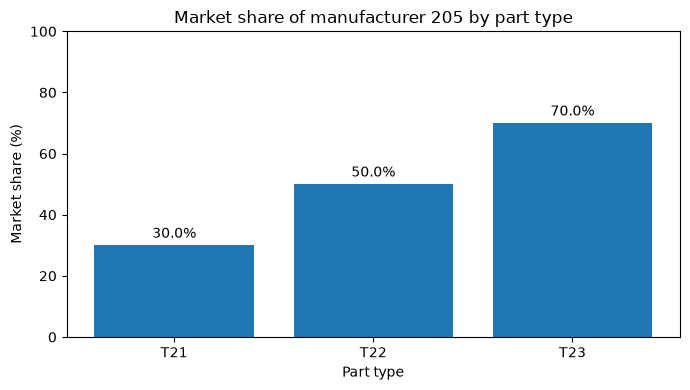

In [38]:
market_share_plot_data = (
    company_parts.groupby("part_type", as_index=False)
    .agg(installed_parts=("installed_parts", "sum"))
)
total_parts_by_type = part_results.groupby("part_type")["installed_parts"].sum()
market_share_plot_data["market_share"] = (
    market_share_plot_data["installed_parts"]
    / market_share_plot_data["part_type"].map(total_parts_by_type)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    market_share_plot_data["part_type"],
    market_share_plot_data["market_share"] * 100,
)
ax.set_title("Market share of manufacturer 205 by part type")
ax.set_xlabel("Part type")
ax.set_ylabel("Market share (%)")
ax.set_ylim(0, 100)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()


## Task 2: Parts From 205 in Gearboxes

Each gearbox is counted once. A gearbox counts as covered by `205` if at least one relevant installed part in that gearbox was produced by manufacturer `205`.


In [39]:
gearbox_coverage_table = gearbox_results[[
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "gearboxes_total",
    "gearboxes_with_205",
    "gearbox_penetration",
    "every_xth_gearbox",
]].sort_values(["vehicle_year", "vehicle_type", "gearbox_family"])

gearbox_coverage_table.head(20)


,vehicle_year,vehicle_type,gearbox_family,gearboxes_total,gearboxes_with_205,gearbox_penetration,every_xth_gearbox
0,2008,11,K3AG1,5211,1608,0.308578,3.240672
1,2008,11,K3SG1,20725,18533,0.894234,1.118276
2,2008,12,K3AG1,1055,308,0.291943,3.425325
3,2008,12,K3SG1,4296,3869,0.900605,1.110364
4,2009,11,K3AG1,49599,14888,0.300167,3.331475
5,2009,11,K3SG1,197635,176693,0.894037,1.118522
6,2009,12,K3AG1,10090,3080,0.305253,3.275974
7,2009,12,K3SG1,40791,36510,0.89505,1.117256
8,2010,11,K3AG1,49413,14821,0.299941,3.333986
9,2010,11,K3SG1,197981,177256,0.895318,1.116921


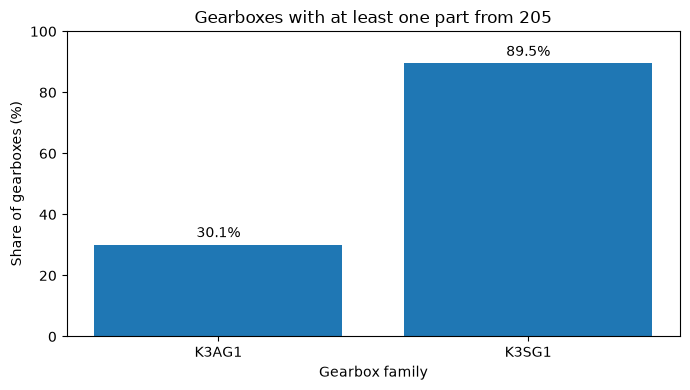

In [40]:
gearbox_coverage_plot_data = (
    gearbox_results.groupby("gearbox_family", as_index=False)
    .agg(
        gearboxes_total=("gearboxes_total", "sum"),
        gearboxes_with_205=("gearboxes_with_205", "sum"),
    )
)
gearbox_coverage_plot_data["gearbox_penetration"] = (
    gearbox_coverage_plot_data["gearboxes_with_205"]
    / gearbox_coverage_plot_data["gearboxes_total"]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    gearbox_coverage_plot_data["gearbox_family"],
    gearbox_coverage_plot_data["gearbox_penetration"] * 100,
)
ax.set_title("Gearboxes with at least one part from 205")
ax.set_xlabel("Gearbox family")
ax.set_ylabel("Share of gearboxes (%)")
ax.set_ylim(0, 100)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()


## Task 3: Relative Defect Frequency

Defect frequency is calculated as defective parts divided by installed parts. The comparison is made between manufacturer `205` and the competing manufacturers for the same relevant part types.


In [41]:
defect_frequency_table = part_results[[
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "part_type",
    "part_manufacturer",
    "installed_parts",
    "defective_parts",
    "defect_frequency",
]].sort_values([
    "vehicle_year",
    "vehicle_type",
    "gearbox_family",
    "part_type",
    "part_manufacturer",
])

defect_frequency_table.head(20)


,vehicle_year,vehicle_type,gearbox_family,part_type,part_manufacturer,installed_parts,defective_parts,defect_frequency
36,2008,11,K3AG1,T21,205,1608,166,0.103234
37,2008,11,K3AG1,T21,207,1023,101,0.098729
38,2008,11,K3AG1,T21,208,2580,284,0.110078
39,2008,11,K3AG1,T24,206,1590,133,0.083648
40,2008,11,K3AG1,T24,207,2066,189,0.091481
41,2008,11,K3AG1,T24,208,1555,150,0.096463
42,2008,11,K3AG1,T25,206,3116,313,0.100449
43,2008,11,K3AG1,T25,207,2095,217,0.10358
44,2008,11,K3SG1,T21,205,6176,623,0.100874
45,2008,11,K3SG1,T21,207,4210,403,0.095724


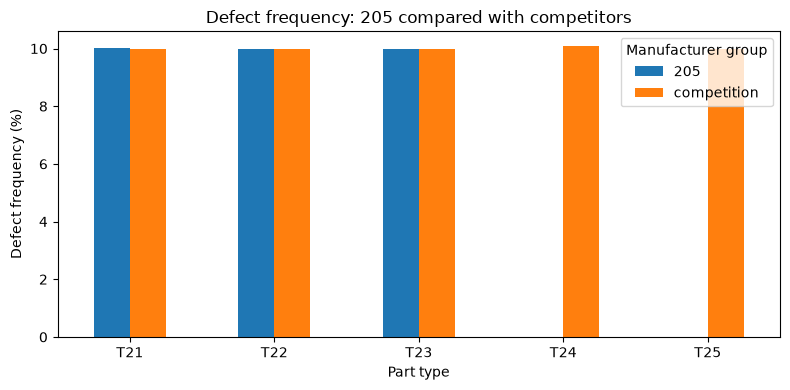

In [42]:
defect_plot_data = (
    part_results.assign(
        manufacturer_group=part_results["is_205"].map(
            {True: "205", False: "competition"}
        )
    )
    .groupby(["part_type", "manufacturer_group"], as_index=False)
    .agg(
        installed_parts=("installed_parts", "sum"),
        defective_parts=("defective_parts", "sum"),
    )
)
defect_plot_data["defect_frequency"] = (
    defect_plot_data["defective_parts"] / defect_plot_data["installed_parts"]
)
defect_plot_pivot = defect_plot_data.pivot(
    index="part_type",
    columns="manufacturer_group",
    values="defect_frequency",
).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
defect_columns = [
    column for column in ["205", "competition"] if column in defect_plot_pivot
]
defect_plot_pivot[defect_columns].mul(100).plot(
    kind="bar",
    ax=ax,
)
ax.set_title("Defect frequency: 205 compared with competitors")
ax.set_xlabel("Part type")
ax.set_ylabel("Defect frequency (%)")
ax.legend(title="Manufacturer group")
plt.xticks(rotation=0)
plt.tight_layout()


## Overall View

This compact view is useful as a first check before deciding which years, vehicle types, gearbox families, or parts should be highlighted in the app.


In [43]:
company_vs_competition = (
    part_results.assign(
        manufacturer_group=part_results["is_205"].map(
            {True: "205", False: "competition"}
        )
    )
    .groupby(["manufacturer_group", "part_type"], dropna=False)
    .agg(
        installed_parts=("installed_parts", "sum"),
        defective_parts=("defective_parts", "sum"),
    )
    .reset_index()
)
company_vs_competition["defect_frequency"] = (
    company_vs_competition["defective_parts"]
    / company_vs_competition["installed_parts"]
)
company_vs_competition = company_vs_competition.sort_values(
    ["part_type", "manufacturer_group"]
)

company_vs_competition


,manufacturer_group,part_type,installed_parts,defective_parts,defect_frequency
0,205,T21,715619,71746,0.100257
3,competition,T21,1669641,166972,0.100005
1,205,T22,954621,95384,0.099918
4,competition,T22,953587,95104,0.099733
2,205,T23,1335746,133506,0.099949
5,competition,T23,572462,57157,0.099844
6,competition,T24,477052,48143,0.100918
7,competition,T25,477052,47623,0.099828


# Report

The analysis starts from the unchanged raw files in `Case_Study_Data`. Before loading the relevant tables, the notebook scans the available files and checks their formats. This was necessary because the raw data is not stored in one consistent structure: some files use different separators, one relevant part file has unusual row breaks, and one individual-part file also appears as a duplicate outside the expected folder. The notebook therefore keeps the raw files untouched and handles these import issues directly in code.

The scope is derived from the task and then checked with the data. We use OEM1 vehicles of type `11` and `12`, identify the installed gearbox families from the vehicle component mappings, and then focus on `K3AG1` and `K3SG1`. From the gearbox component files, the relevant individual part types are derived as `T21`, `T22`, `T23`, `T24`, and `T25`. This connects the business focus on gearbox parts to the actual files that are needed for the analysis.

After cleaning, the relevant vehicle, gearbox, and part tables are merged through their IDs. The joins are checked with the expected relationships: vehicles to gearbox production records, gearboxes to installed parts, and installed parts to part production records. The detailed validation table contains 7,155,780 installed relevant parts in 2,385,260 gearboxes. There are no missing vehicle IDs, gearbox IDs, part IDs, or part manufacturer values in the final detailed table. A small number of negative gearbox mileage values is documented during preparation, but mileage is not used for the three requested calculations.

The exported final dataset is aggregated into two record types. `part_summary` contains the counts needed for market share and defect frequency by year, vehicle type, gearbox family, part type, and manufacturer. `gearbox_summary` contains the counts needed to determine how many gearboxes contain at least one relevant part from manufacturer `205`. The dataset is stored in `Data/SoSe26_Case_Study_finalData_Group_01.csv` and also copied to the project root for submission convenience.

For market share, manufacturer `205` is present in three of the five relevant part types. The strongest position is in `T23`, where `205` reaches about 70.0 percent market share. For `T22`, `205` is almost equal to the competition with about 50.0 percent. For `T21`, the market share is about 30.0 percent. In `T24` and `T25`, no parts from `205` are installed in the selected gearbox data. Overall, `205` supplies about 42.0 percent of all relevant parts.

For the gearbox slogan, parts from `205` are installed in 1,851,339 out of 2,385,260 relevant gearboxes. This is about 77.6 percent of all considered gearboxes, or roughly every 1.29th gearbox. The result is especially strong for `K3SG1`, where about 89.5 percent of gearboxes contain at least one relevant part from `205`.

For quality, the relative defect frequency of `205` is very close to the competition. Across all relevant parts, `205` has a defect frequency of about 10.001 percent, while the competition is at about 10.000 percent. Based on the current dataset, there is no clear quality advantage for `205`. The quality claim should therefore be handled carefully unless a later filter or additional statistical check supports it.
